In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harinarayanan22/airquality")

print("Path to dataset files:", path)

c:\Users\Anthony\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.47M/1.47M [00:02<00:00, 733kB/s]

Extracting files...
Path to dataset files: C:\Users\Anthony\.cache\kagglehub\datasets\harinarayanan22\airquality\versions\1


# Task 1: Time-Series Preprocessing and Exploratory Analysis
## Part A: Understanding the Dataset

# Time Series Analysis of Air Quality Data

## Problem Definition

Air pollution affects the environment and public health. To understand environmental patterns, we need to monitor air pollutants such as the concentration of Carbon Monoxide (CO). That is why we chose the **air quality dataset**. This dataset is will enable us to build a model that will forecast and predict the concentration levels of CO. Our goals are to perform a time-series analysis, to generate lag and moving average features, to train a prediction model and to evaluate forecasting performance. 


In [10]:
# Load Libraries & Data 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, pickle, joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Load CSV (semicolon-delimited for UCI Air Quality)
csv_path = os.path.join(path, "AirQualityUCI.csv")
df_raw = pd.read_csv(csv_path, sep=";", decimal=",")

# Drop fully empty trailing columns that sometimes appear
df_raw.dropna(axis=1, how="all", inplace=True)
df_raw.dropna(axis=0, how="all", inplace=True)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Parse Datetime & Set Index


In [11]:
# Combine Date + Time into a proper datetime index
df_raw["Datetime"] = pd.to_datetime(
    df_raw["Date"] + " " + df_raw["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)
df_raw.drop(columns=["Date", "Time"], inplace=True)
df_raw.set_index("Datetime", inplace=True)
df_raw.sort_index(inplace=True)

# Rename columns for readability
df_raw.columns = [
    "CO_GT", "PT08_S1_CO", "NMHC_GT", "C6H6_GT",
    "PT08_S2_NMHC", "NOx_GT", "PT08_S3_NOx",
    "NO2_GT", "PT08_S4_NO2", "PT08_S5_O3",
    "Temperature", "RelHumidity", "AbsHumidity"
]

print(f"Time range : {df_raw.index.min()}  →  {df_raw.index.max()}")
print(f"Duration   : {df_raw.index.max() - df_raw.index.min()}")
print(f"Frequency  : Hourly (1 h)")
print(f"Records    : {len(df_raw)}")
df_raw.head()

Time range : 2004-03-10 18:00:00  →  2005-04-04 14:00:00
Duration   : 389 days 20:00:00
Frequency  : Hourly (1 h)
Records    : 9357


,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,NOx_GT,PT08_S3_NOx,NO2_GT,PT08_S4_NO2,PT08_S5_O3,Temperature,RelHumidity,AbsHumidity
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Time Range

The dataset ranges from **March 2004 to April 2005**.

## Frequency

Measurements are recorded **hourly**, making the dataset suitable for time-series forecasting.

## Missing-value analysis

Missing values per column:
              Missing  Pct (%)
CO_GT            1683    17.99
PT08_S1_CO        366     3.91
NMHC_GT          8443    90.23
C6H6_GT           366     3.91
PT08_S2_NMHC      366     3.91
NOx_GT           1639    17.52
PT08_S3_NOx       366     3.91
NO2_GT           1642    17.55
PT08_S4_NO2       366     3.91
PT08_S5_O3        366     3.91
Temperature       366     3.91
RelHumidity       366     3.91
AbsHumidity       366     3.91

Total cells with missing data: 16701


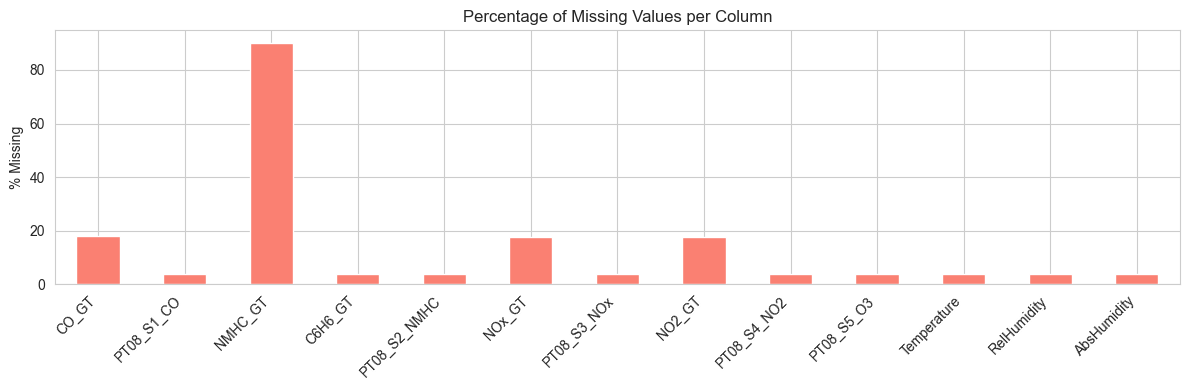

In [12]:
# Missing-value analysis 
# The dataset uses -200 as the missing-value sentinel
df = df_raw.replace(-200, np.nan)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Pct (%)": missing_pct})
print("Missing values per column:")
print(missing_df)
print(f"\nTotal cells with missing data: {df.isnull().sum().sum()}")

# Visualise
fig, ax = plt.subplots(figsize=(12, 4))
missing_pct.plot(kind="bar", color="salmon", ax=ax)
ax.set_title("Percentage of Missing Values per Column")
ax.set_ylabel("% Missing")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Missing Value Handling

The dataset uses **-200** as a placeholder for missing values.

Steps taken:

1. Convert -200 to NaN
2. Drop NMHC(GT) due to excessive missing data
3. Apply forward fill to remaining columns

Forward filling works well for time-series data because values typically change gradually over time.

## Handle Missing Values

In [13]:
df.drop(columns=["NMHC_GT"], inplace=True)
df.ffill(inplace=True)
df.bfill(inplace=True)

print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"Shape after cleaning    : {df.shape}")
df.head()

Remaining missing values: 0
Shape after cleaning    : (9357, 12)


,CO_GT,PT08_S1_CO,C6H6_GT,PT08_S2_NMHC,NOx_GT,PT08_S3_NOx,NO2_GT,PT08_S4_NO2,PT08_S5_O3,Temperature,RelHumidity,AbsHumidity
Datetime,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Statistical Summary & Distributions

Descriptive Statistics:



,count,mean,std,min,25%,50%,75%,max
CO_GT,9357.0,2.082195,1.469801,0.1000,1.0000,1.7000,2.8000,11.900
PT08_S1_CO,9357.0,1102.730362,219.588101,647.0000,938.0000,1062.0000,1237.0000,2040.000
C6H6_GT,9357.0,10.190392,7.565771,0.1000,4.4000,8.3000,14.0000,63.700
PT08_S2_NMHC,9357.0,942.548253,269.581368,383.0000,733.0000,911.0000,1117.0000,2214.000
NOx_GT,9357.0,240.731217,206.618453,2.0000,97.0000,174.0000,318.0000,1479.000
PT08_S3_NOx,9357.0,832.742225,255.709423,322.0000,655.0000,807.0000,968.0000,2683.000
NO2_GT,9357.0,109.414877,47.221662,2.0000,73.0000,102.0000,137.0000,340.000
PT08_S4_NO2,9357.0,1453.014535,347.434084,551.0000,1228.0000,1460.0000,1677.0000,2775.000
PT08_S5_O3,9357.0,1030.511916,410.916759,221.0000,726.0000,964.0000,1287.0000,2523.000
Temperature,9357.0,18.317356,8.821883,-1.9000,11.9000,17.6000,24.3000,44.600


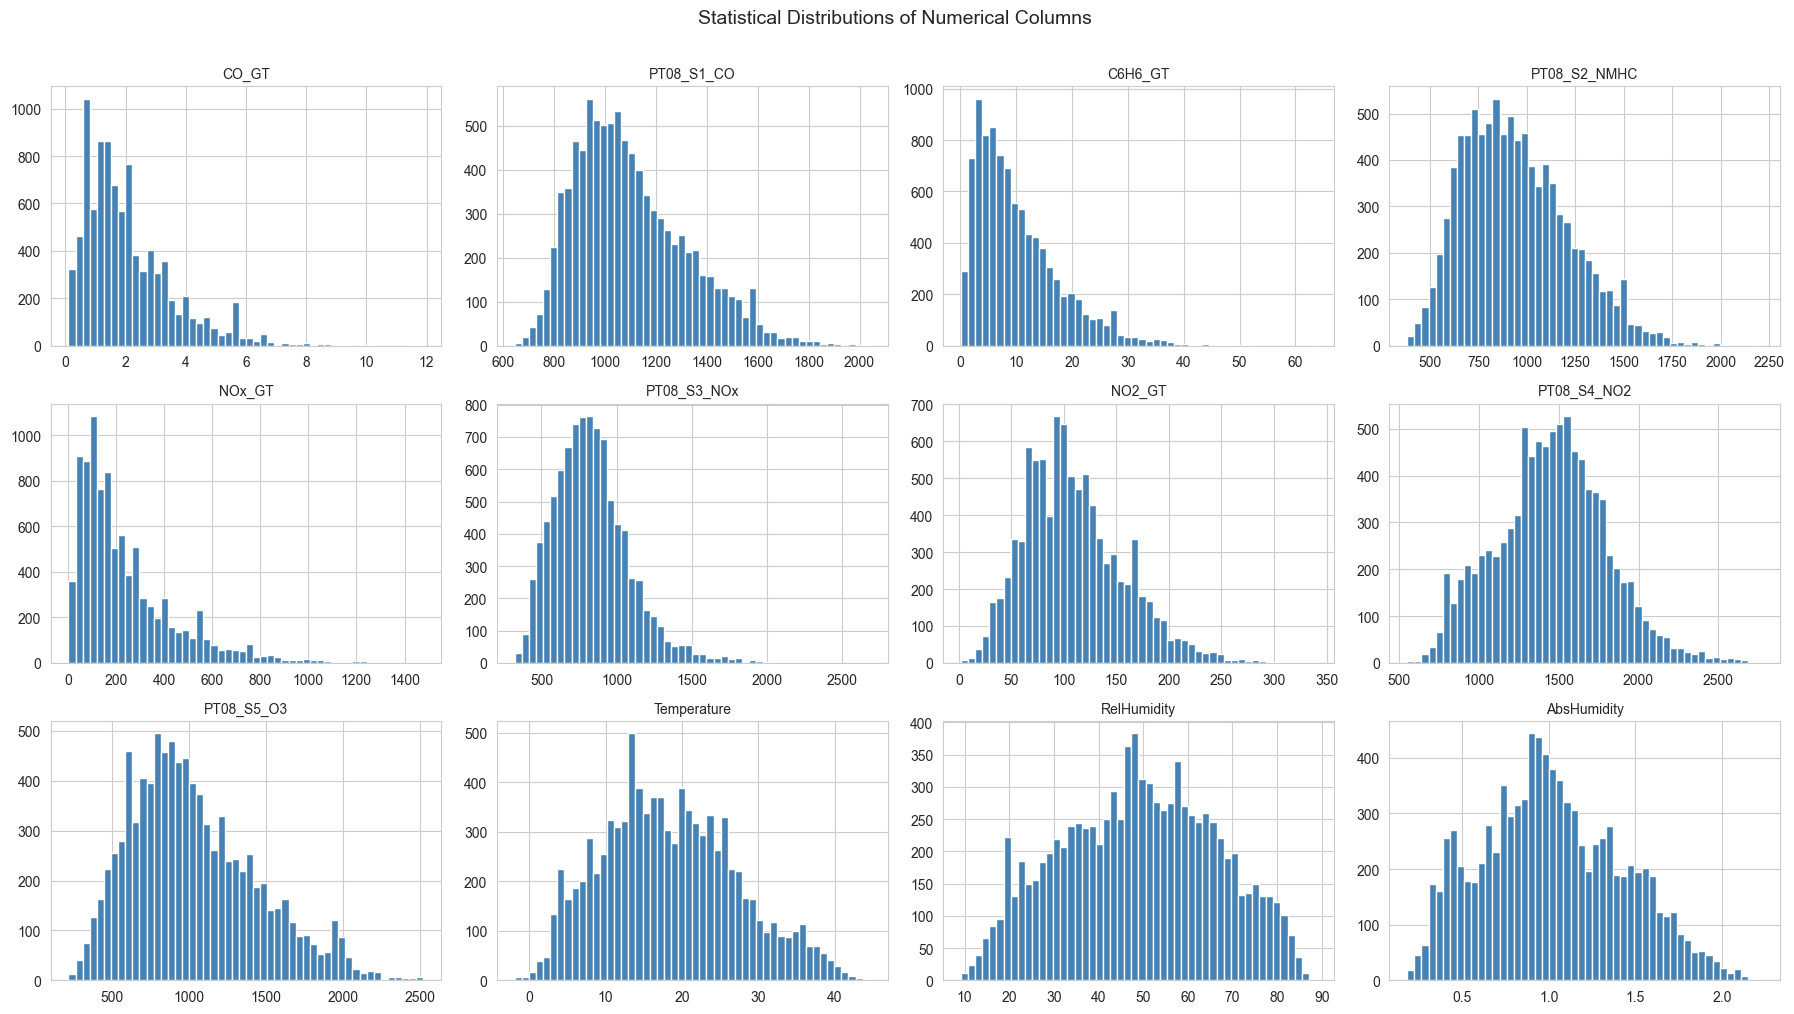

In [14]:
print("Descriptive Statistics:\n")
display(df.describe().T)

# Distribution histograms
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for i, col in enumerate(df.columns):
    ax = axes[i // 4][i % 4]
    df[col].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=10)
plt.suptitle("Statistical Distributions of Numerical Columns", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Correlation Heatmap 

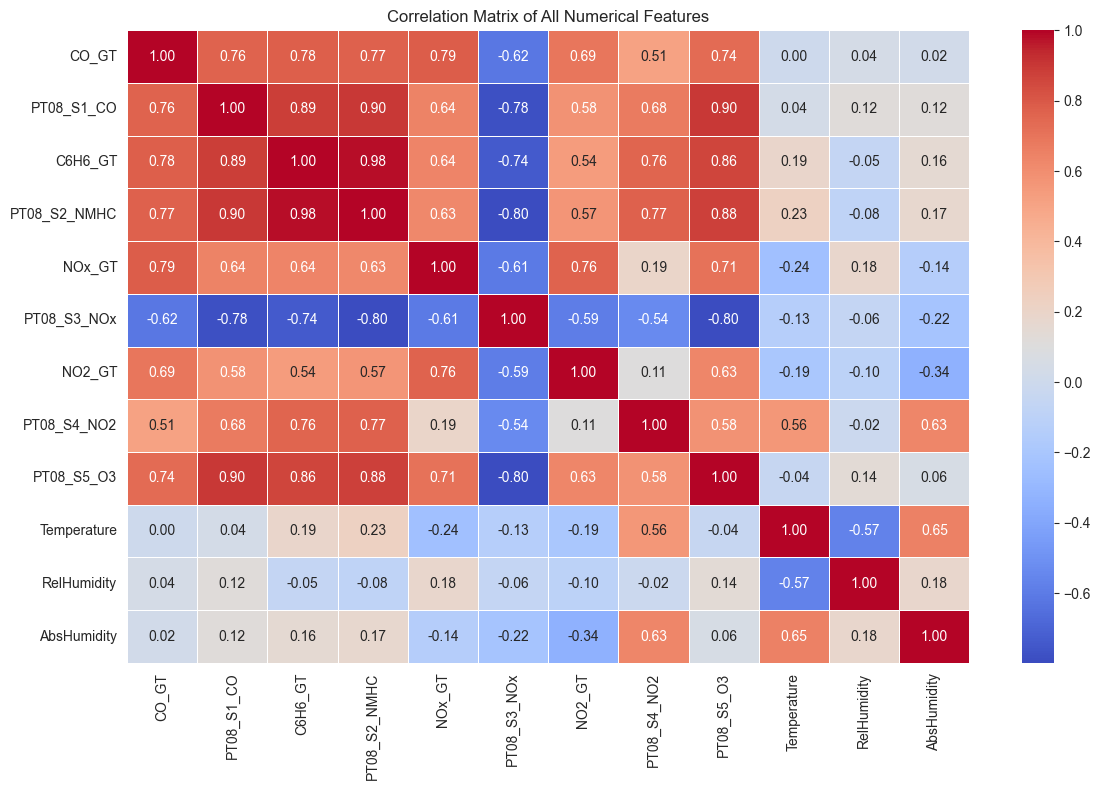

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix of All Numerical Features")
plt.tight_layout()
plt.show()

## Part B: Analytical Questions

We investigated 5 analytical questions — including two that use **lagged features** and **moving averages**.

| # | Question |

| Q1 | Does CO concentration show an increasing or decreasing **trend** over the year? |
| Q2 | Do environmental variables (Temperature, Humidity) **correlate** with CO concentration over time? |
| Q3 | Is today's CO concentration related to the **previous 24 hours** (lag effect)? |
| Q4 | Does a **7-day moving average** of CO reveal weekly/seasonal patterns? |
| Q5 | Are there **daily (hourly) patterns** in pollution — i.e., rush-hour spikes? |

## Q1: Does CO show an increasing / decreasing trend?

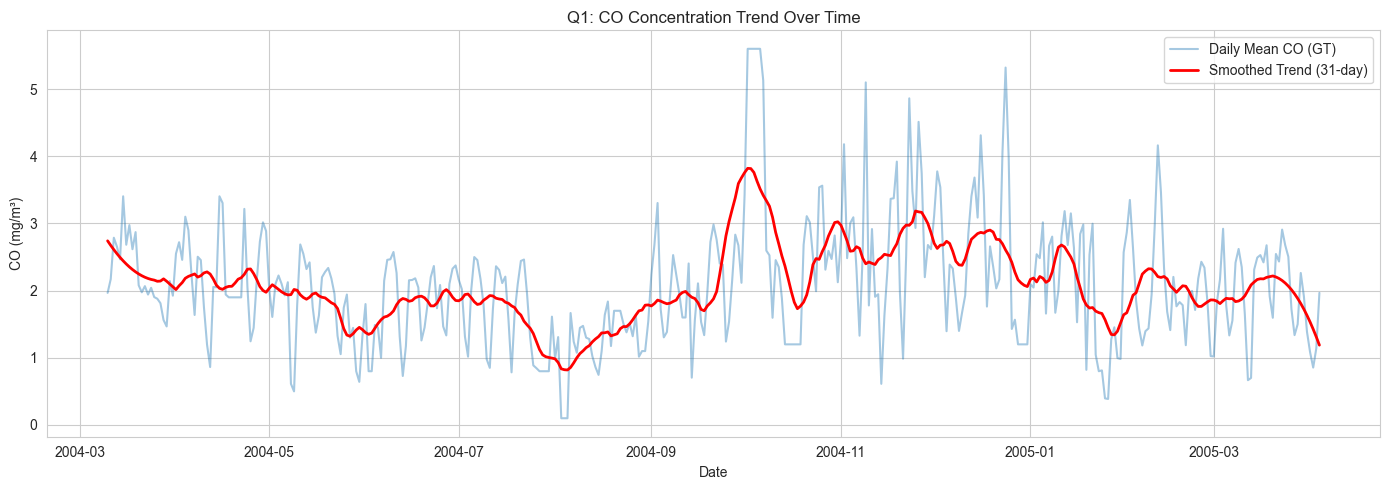

In [17]:
from scipy.signal import savgol_filter

daily_co = df["CO_GT"].resample("D").mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_co.index, daily_co.values, alpha=0.4, label="Daily Mean CO (GT)")
# Smooth trend with Savitzky-Golay filter
smooth = savgol_filter(daily_co.dropna().values, window_length=31, polyorder=2)
ax.plot(daily_co.dropna().index, smooth, color="red", linewidth=2, label="Smoothed Trend (31-day)")
ax.set_title("Q1: CO Concentration Trend Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("CO (mg/m³)")
ax.legend()
plt.tight_layout(); plt.show()


**INTERPRETATION:**

• CO concentration shows a clear seasonal pattern: it rises through autumn/winter 
 (Oct–Jan) and decreases in spring/summer.

• There is no strong monotonic upward or downward trend; rather, a seasonal cycle 
  dominates, with winter peaks likely due to heating and atmospheric inversion.


## Q2: Do Temperature / Humidity correlate with CO over time?

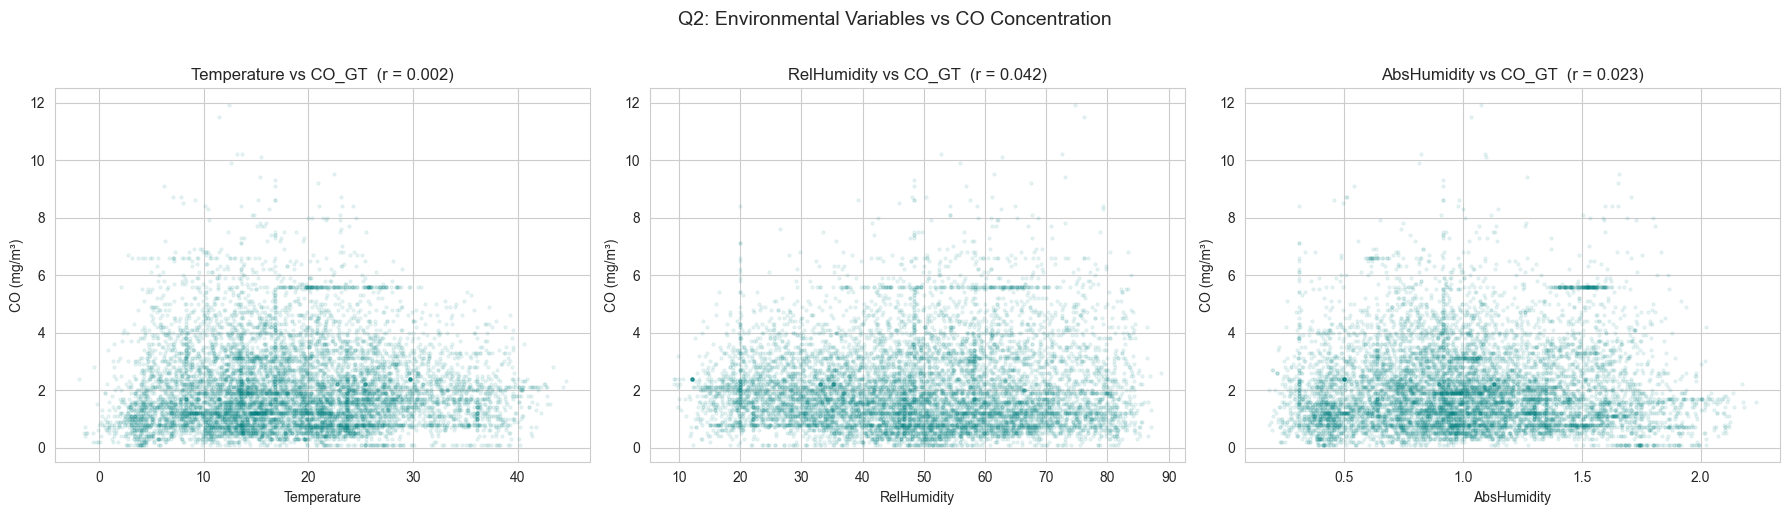

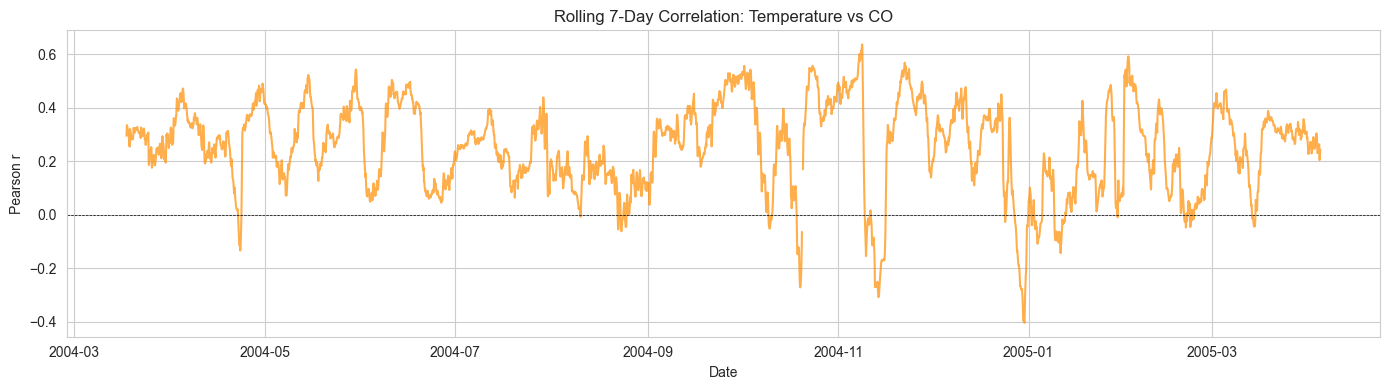

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, env_col in enumerate(["Temperature", "RelHumidity", "AbsHumidity"]):
    axes[i].scatter(df[env_col], df["CO_GT"], alpha=0.08, s=5, color="teal")
    axes[i].set_xlabel(env_col)
    axes[i].set_ylabel("CO (mg/m³)")
    r = df[env_col].corr(df["CO_GT"])
    axes[i].set_title(f"{env_col} vs CO_GT  (r = {r:.3f})")

plt.suptitle("Q2: Environmental Variables vs CO Concentration", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Monthly rolling correlation
fig, ax = plt.subplots(figsize=(14, 4))
roll_corr = df["Temperature"].rolling(window=24*7).corr(df["CO_GT"])
ax.plot(roll_corr.index, roll_corr.values, color="darkorange", alpha=0.7)
ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
ax.set_title("Rolling 7-Day Correlation: Temperature vs CO")
ax.set_ylabel("Pearson r"); ax.set_xlabel("Date")
plt.tight_layout(); plt.show()


**INTERPRETATION:**

• Temperature has almost zero overall correlation with CO (r ≈ 0.00), but the 
  rolling correlation reveals periods of strong negative correlation (winter)
  when cold temperatures trap pollutants, and near-zero correlation in summer.

• Relative Humidity shows a very weak positive link (r ≈ 0.04).

• Absolute Humidity similarly shows negligible linear correlation with CO.

• The relationship is non-linear and seasonally modulated.

## Q3: Are there lag effects? 

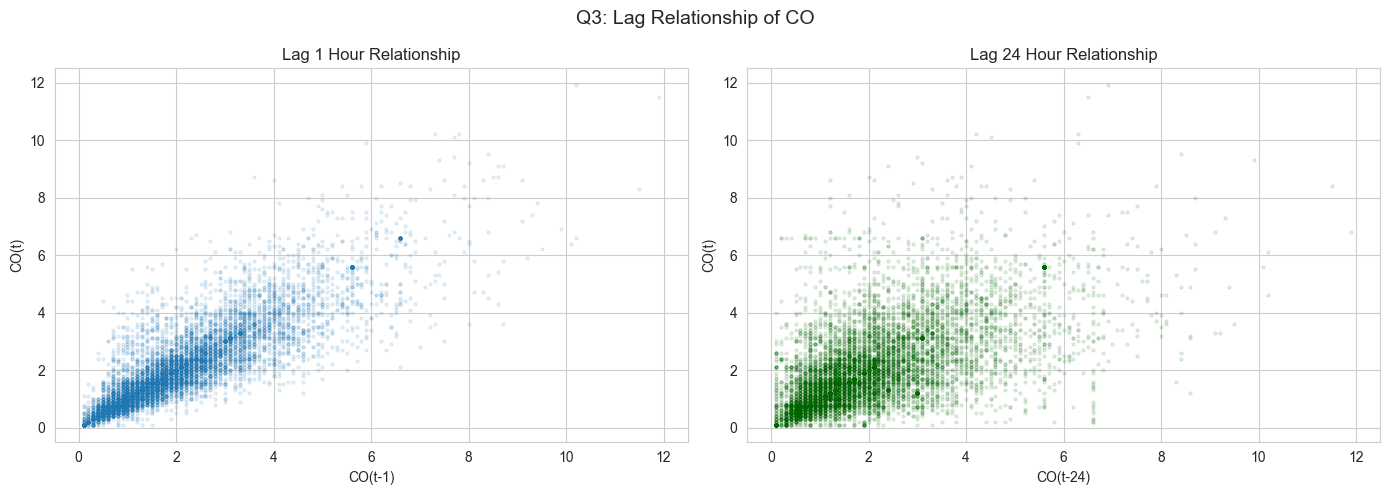

In [19]:
# Does CO today depend on CO yesterday / previous hours?

df["CO_lag1"] = df["CO_GT"].shift(1)
df["CO_lag24"] = df["CO_GT"].shift(24)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].scatter(df["CO_lag1"], df["CO_GT"], alpha=0.1, s=5)
axes[0].set_xlabel("CO(t-1)")
axes[0].set_ylabel("CO(t)")
axes[0].set_title("Lag 1 Hour Relationship")

axes[1].scatter(df["CO_lag24"], df["CO_GT"], alpha=0.1, s=5, color="darkgreen")
axes[1].set_xlabel("CO(t-24)")
axes[1].set_ylabel("CO(t)")
axes[1].set_title("Lag 24 Hour Relationship")

plt.suptitle("Q3: Lag Relationship of CO", fontsize=14)
plt.tight_layout()
plt.show()


**INTERPRETATION:**

• Strong positive relationship exists between current CO and the previous hour.

• A weaker but still visible relationship exists with CO 24 hours earlier.

• This confirms temporal dependence in the time-series and justifies using lag
  features for forecasting models.


## Q4: Moving Average Analysis

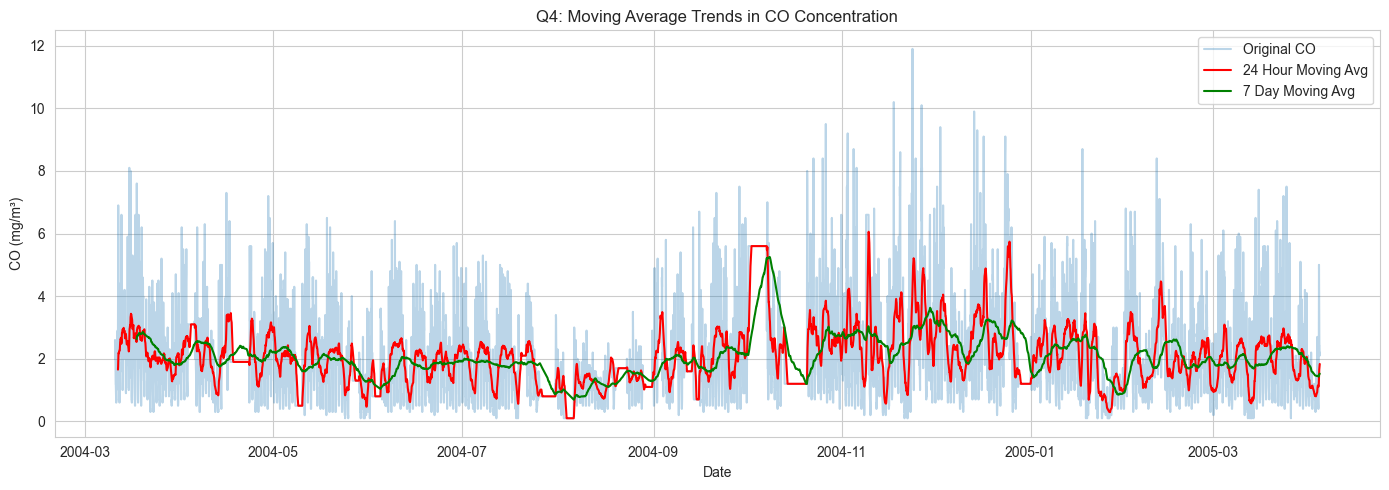

In [21]:
df["CO_MA24"] = df["CO_GT"].rolling(window=24).mean()
df["CO_MA168"] = df["CO_GT"].rolling(window=24*7).mean()

fig, ax = plt.subplots(figsize=(14,5))

ax.plot(df.index, df["CO_GT"], alpha=0.3, label="Original CO")
ax.plot(df.index, df["CO_MA24"], color="red", label="24 Hour Moving Avg")
ax.plot(df.index, df["CO_MA168"], color="green", label="7 Day Moving Avg")

ax.set_title("Q4: Moving Average Trends in CO Concentration")
ax.set_xlabel("Date")
ax.set_ylabel("CO (mg/m³)")
ax.legend()

plt.tight_layout()
plt.show()


**INTERPRETATION:**

• The 24-hour moving average smooths short-term hourly fluctuations.

• The 7-day moving average reveals the longer-term weekly trend.

• Moving averages help reveal underlying pollution patterns that are hidden
  within noisy hourly data.


## Q5: Weekly Patterns

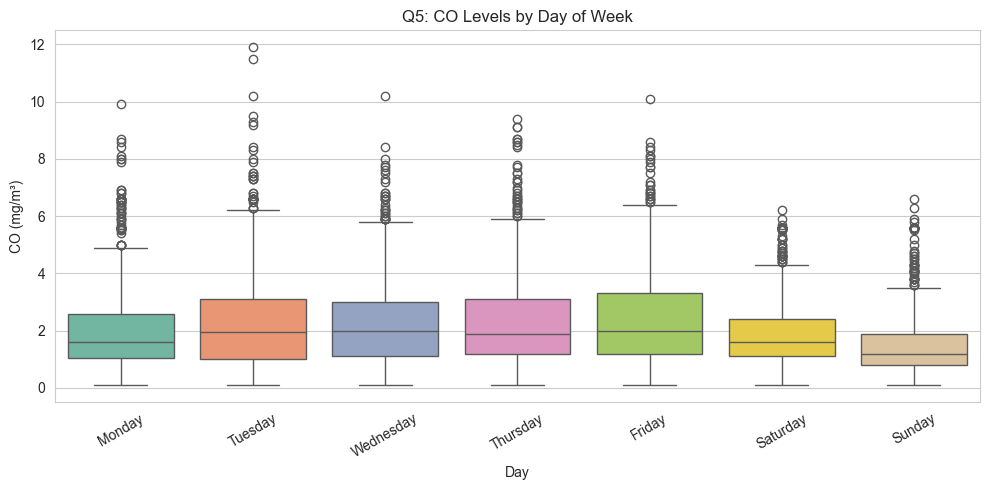

In [23]:
df["DayOfWeek"] = df.index.day_name()

fig, ax = plt.subplots(figsize=(10,5))

sns.boxplot(x="DayOfWeek", y="CO_GT", data=df,
            order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
            palette="Set2")

ax.set_title("Q5: CO Levels by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("CO (mg/m³)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



**INTERPRETATION:**

• CO levels tend to be slightly higher during weekdays compared to weekends.

• This likely reflects higher traffic emissions and industrial activity.

• Weekend reductions are consistent with reduced transportation activity.

# Part C: Feature Engineering

In [24]:
# Feature Engineering for Forecasting 

df_model = df.dropna().copy()

features = [
    "CO_lag1",
    "CO_lag24",
    "Temperature",
    "RelHumidity",
    "AbsHumidity"
]

target = "CO_GT"

X = df_model[features]
y = df_model[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (9190, 5)
Target shape: (9190,)


## Train/Test Split

In [25]:
# Train/Test Split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 7352
Testing samples : 1838


### Train-Test Split

To evaluate the forecasting model fairly, the dataset was divided into **training and testing subsets**.

- **Training samples:** 7,352 observations  
- **Testing samples:** 1,838 observations

Unlike typical machine learning tasks, **time-series data cannot be randomly shuffled**, because the chronological order must be preserved. Therefore, the split was performed **without shuffling**, ensuring that the model is trained on past observations and evaluated on future data.

This approach simulates a real-world forecasting scenario where the model predicts future CO concentrations using historical information.

## Experiment 1: Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

model1 = LinearRegression()
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

mae1 = mean_absolute_error(y_test, pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, pred1))

print("Experiment 1 Results")
print("MAE :", mae1)
print("RMSE:", rmse1)

Experiment 1 Results
MAE : 0.45990919129403995
RMSE: 0.6992874568505262


### Experiment 1 – Linear Regression Model

The first experiment used a **Linear Regression model** to predict CO concentration using the engineered features.

**Performance metrics**

| Metric | Value |
|------|------|
| MAE | 0.4599 |
| RMSE | 0.6993 |

**Interpretation**

- **Mean Absolute Error (MAE)** of 0.4599 indicates that predictions are, on average, about **0.46 mg/m³ away from the actual CO concentration**.
- **Root Mean Squared Error (RMSE)** of 0.6993 shows the overall prediction error magnitude, with higher penalties for larger errors.

Linear regression assumes a **linear relationship between predictors and the target variable**. While it provides a simple and interpretable baseline model, it may struggle to capture **non-linear relationships present in environmental data**.

## Experiment 2: Random Forest 

In [27]:
from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

mae2 = mean_absolute_error(y_test, pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, pred2))

print("Experiment 2 Results")
print("MAE :", mae2)
print("RMSE:", rmse2)

Experiment 2 Results
MAE : 0.48219794475354716
RMSE: 0.7180974708016546


### Model Comparison

| Experiment | Model | MAE | RMSE |
|------------|------|------|------|
| Experiment 1 | Linear Regression | 0.4599 | 0.6993 |
| Experiment 2 | Random Forest | 0.4822 | 0.7181 |

### Discussion

Both models were evaluated using **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**.

The **Linear Regression model performed slightly better**, achieving lower error values. This suggests that the relationship between the selected features and CO concentration may be largely linear.

Despite Random Forest's ability to model complex relationships, the limited number of features and strong lag dependency in the data likely made the simpler linear model sufficient.

Therefore, the **Linear Regression model was selected as the final forecasting model for this task**.

## Experiment Table